## Esercizio 1

In questo esercizio ipotizzeremo che sia fisso il numero di volte, nell'arco di un mese, che in un centro medico viene eseguito un dato esame. Indicato con oЄN tale numero, sia pЄ[0, 1] la probabilità che un utente che effettua l'esame non debba pagare la prestazione medica, perché è coperto dal sistema sanitario pubblico. Siano, infine, $X1,... Xo$ delle variabili aleatorie, ognuna delle quali assume le seguenti specificazioni:

- 1 quando la prestazione per l'i-esimo esame è riconosciuta dal sistema sanitario
- 0 altrimenti

1. Che distribuzione segue $X$, indipendentemente dal valore di i?

2. Che motivazioni utilizzereste per sostenere che le variabili aleatorie $X1,..., Xo$ sono i.i.d.?

3. Sia $M$ la somma da i a o di $Xi$. Quando si verifica l'evento $M$=m?

4. Che distribuzione segue $M$?

5. Indichiamo con $R$ la variabile aleatoria che indica il rimborso totale ottenuto dal centro medico in un mese. Esprimete $R$ in funzione r e di una o più tra le variabili aleatorie introdotte, scegliendole opportunamente. Esprimete poi la probabilità P(R) in funzione di o, p, r e x.

6. Calcolate il valore atteso e la varianza di R, esprimendoli in funzione di r, o e p

7. Solo in questo punto fissiamo r = 35, o = 40 e p=0.2. Disegnate il grafico della funzione di massa di probabilità di R e commentate il risultato ottenuto

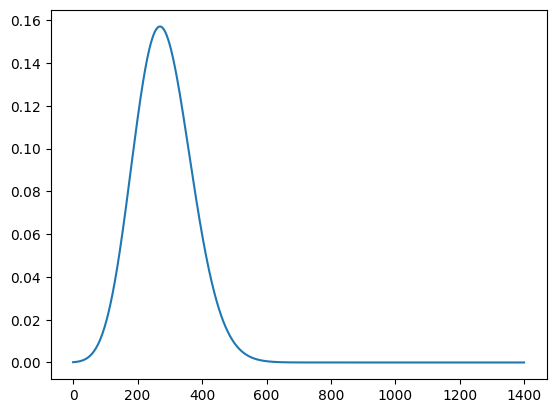

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.special import factorial, binom
import statsmodels.api as sm

r = 35
o = 40
p = 0.2

x = np.arange(0,o*r)
y = binom(o, x/r) * p**(x/r) * (1 - p)**(o - x/r)

plt.plot(x,y)
plt.show()

## Esercizio 2

In questo esercizio considereremo una popolazione $R$ la cui distribuzione è la stessa dell'omonima variabile aleatoria introdotta nell'esercizio precedente e che assumeremo nota a meno del solo parametro r. Per n€$N$ fissato, $R1,...,Rn$ indicheranno delle variabili aleatorie che descrivono un campione estratto da $R$.

1. Sia R' la variabile aleatoria che indica la media campionaria calcolata su R1,...,Rn. Esprimete il suo valore atteso in funzione di r, o e p

2. Utilizzate il metodo plug-in per individuare uno stimatore T che risulti non distorto per il parametro r della distribuzione di $R$

3. Sia $S2$ la variabile aleatoria che indica la varianza campionaria calcolata su $R1,...,Rn$ Applicate il metodo plug-in per proporre uno stimatore $U$ di r che dipenda da $S2$. Lo stimatore che avete determinato gode delle stesse proprietà di T? Perché?

- Nel resto di questo esercizio ci concentreremo sullo stimatore T che avete ottenuto al punto 2.

4. Calcolate lo scarto quadratico medio di $T$, esprimendolo in funzione di r, o, p ed n.

5. Determinate se $T$ gode della proprietà di consistenza in media quadratica, motivando la vostra conclusione.

6. Determinate se T gode della proprietà di consistenza in senso debole, motivando la vostra conclusione.

7. Calcolate la probabilità dell'evento che si verifica quando l'errore (in valore assoluto) che si compie 
usando T per stimarer sia minore o uguale di 1/2, esprimendola in funzione di r, o, p, n e della funzione di ripartizione della distribuzione normale standard, giustificando i vostri passaggi e indicando eventuali approssimazioni che è necessario introdurre.

## ESERCIZIO 3

Il file esami.csv contiene le seguenti informazioni, raccolte dal reparto di analisi dei dati del centro medico e che descrivono un campione di osservazioni relativame all'esame sul quale ci siamo concentrati finora.
⚫ mese: mese di riferimento, indicato come numero che va da uno (gennaio) a dodici (dicembre);
⚫ tot_pagato: somma totale incassata dal centro medico nel mese di riferimento, relativa agli utenti che hanno pagato l'esame di tasca propria;
⚫ tot_rimborsato: rimborso totale che il sistema sanitario nazionale ha inviato al centro medico nel mese di riferimento.
In questo file , il carattere, separa le colonne.

1. Scrivete ed eseguite del codice che visualizzi su righe differenti il nome di ogni attributo unitamente al corrispondente numero di valori mancanti.

2. Di che tipo è l'attributo mese? Sulla base della risposta data, visualizzate la distribuzione di questo attributo fornendo sia una formulazione tabulare, sia un grafico, motivando le vostre scelte.

3. Commentate i risultati ottenuti al punto precedente.

4. Spiegate perché ha senso valutare l'ipotesi che vi sia una relazione tra gli attributi mese e tot_rimborsato. Procedete poi con questa valutazione, motivando la scelta degli strumenti utilizzati e indicando eventualmente il tipo e la forza della relazione determinata.

5. Gli esperti del centro medico sospettano che l'esame in questione venga rimborsato soprattutto nei mesi invernali (dicembre, gennaio e febbraio). Per verificare questa ipotesi, aggiungete al dataset un attributo inverno che vale 1 per i casi che corrispondono ai mesi invernali e 0 altrimenti, e verificate l'esistenza di una relazione tra questo nuovo attributo e tot_rimborsato, evidenziando i caratteri della relazione determinata

6. Verificate se l'ipotesi che i valori di tot rimborsato siano assimilabili a un campione estratto da una distribuzione normale, analizzando prima tutti i casi del dataset, poi solo quelli che fanno riferimento ai mesi invernali e infine solo quelli che fanno riferimento ai mesi rimanenti. Commentate i risultati ottenuti alla luce di quanto visto nel punto precedente e nell'ultimo punto del primo esercizio.p

In [13]:
dati = pd.read_csv('esami.csv')

print(dati.isnull().sum())

mese              0
tot_pagato        0
tot_rimborsato    0
dtype: int64


int64
mese
1     0.093333
2     0.066667
3     0.083333
4     0.076667
5     0.073333
6     0.056667
7     0.103333
8     0.083333
9     0.090000
10    0.073333
11    0.076667
12    0.123333
Name: proportion, dtype: float64


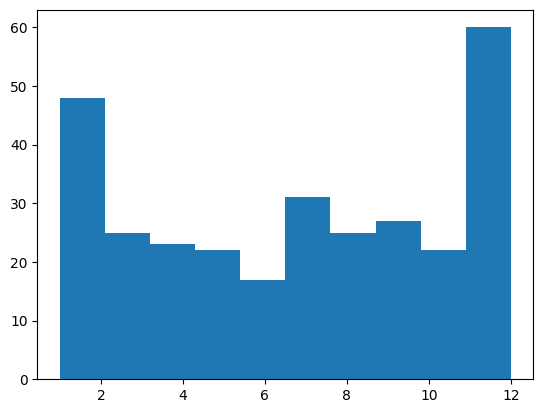

In [21]:
print(dati.mese.dtype)
print(dati.mese.value_counts(normalize=True).sort_index())

plt.hist(dati.mese.sort_index())
plt.show()

# cazzo devo commentare, belli, ci sono più rimborsi di inverno WOOOOOOWWWW

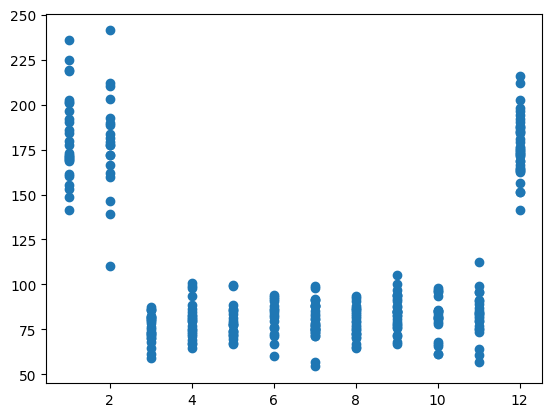

-0.11601776338215178


In [28]:
plt.scatter(dati.mese.sort_index(), dati.tot_rimborsato)
plt.show()

print(dati.mese.corr(dati.tot_rimborsato))

0.6305009241696592


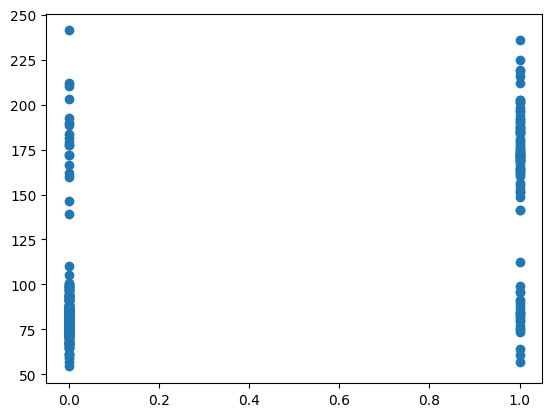

In [59]:
dati["inverno"] = ((dati.mese == 1) | (dati.mese == 12) | (dati.mese == 11)).astype(int)

print(dati.inverno.corr(dati.tot_rimborsato))

plt.scatter(dati.inverno, dati.tot_rimborsato)
plt.show()

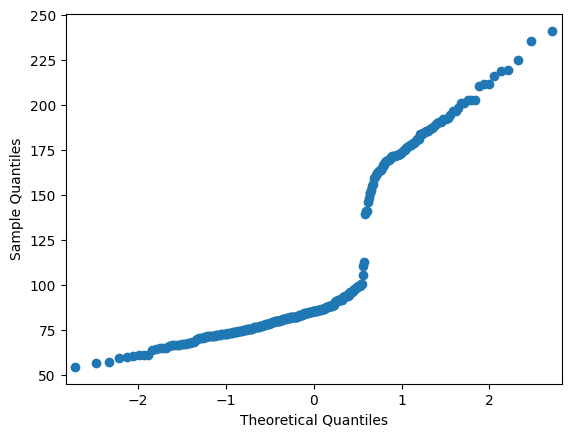

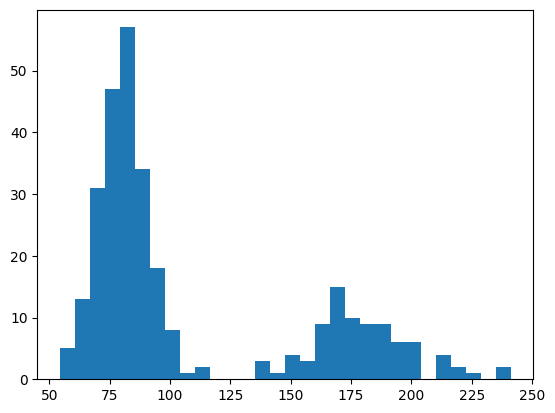

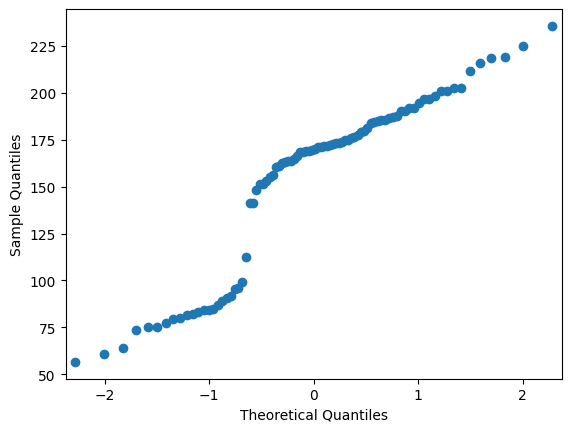

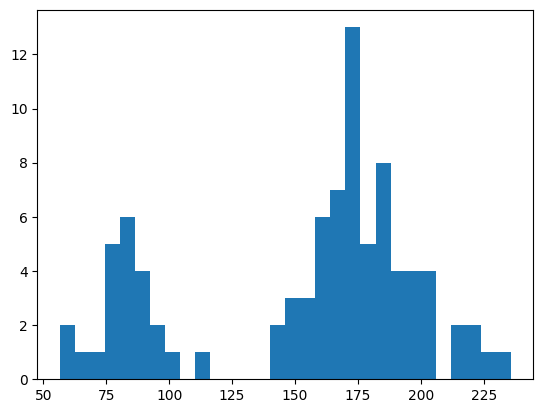

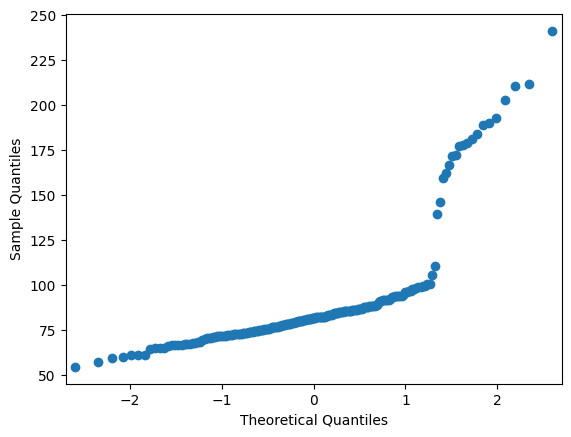

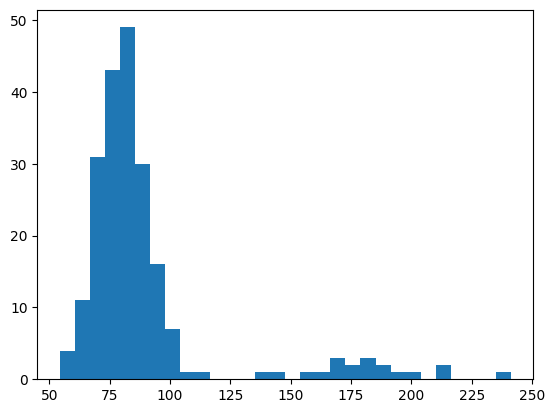

In [64]:
sm.qqplot(dati.tot_rimborsato)
plt.show()

plt.hist(dati.tot_rimborsato, bins=30)
plt.show()

sm.qqplot(dati[dati["inverno"] == 1].tot_rimborsato)
plt.show()

plt.hist(dati[dati["inverno"] == 1].tot_rimborsato, bins=30)
plt.show()

sm.qqplot(dati[dati["inverno"] == 0].tot_rimborsato)
plt.show()

plt.hist(dati[dati["inverno"] == 0].tot_rimborsato, bins=30)
plt.show()

## ESERCIZIO 4

Un ex dipendente del centro medico vuole aprire una sua struttura ed entrare in concorrenza con il suo precedente datore di lavoro. È già a conoscenza del fatto che o = 400 e p = 0.2, ma non conosce il valore r rimborsato dal sistema sanitario pubblico. Avendo trafugato il dataset che abbiamo studiato nell'esercizio precedente, decide di utilizzarlo per stimare r, lavorando esclusivamente sui dati relativi ai mesi invernali, che considereremo come un campione aleatorio R1,...,Rn estratto dalla variabile aleatoria R introdotta nell'Esercizio 2.

1. Sulla base della soluzione che avete proposto per l'Esercizio 2, calcolate una stima adeguata per r.

2. Come potete adattare il risultato dell'Esercizio 2.7 per ottenere la probabilità che la stima ottenuta al punto precedente comporti un errore (in valore assoluto) minore o uguale di mezzo euro? Calcolate questa probabilità.

3. Indichiamo con P la variabile aleatoria che indica l'introito mensile dovuto ai clienti paganti. Stimate il valore atteso e la deviazione standard di P dal campione considerato, e memorizzateli in due variabili mu pe sigma p. Memorizzate poi nelle variabili mu r e sigma_r le stime di valore atteso e deviazione standard della variabile aleatoria R, ottenute considerando i risultati dell'Esercizio 1.6 e sostituendo a r la stima precedentemente ricavata. Nel resto dell'esercizio, approssimeremo le distribuzioni di Re di P con delle opportune leggi gaussiane.

4. Il centro medico che l'ex dipendente si appresta ad aprire dovrà sostenere delle spese fisse mensili di 25000 Euro. Indichiamo con F l'evento che si verifica se in un mese i soldi ottenuti dai clienti paganti e dal sistema sanitario non sono sufficienti a coprire queste spese. Esprimete F in termini delle variabili aleatorie R e P, e calcolate poi P(F).

5. Supponendo che i ricavi (o le perdite) di mesi differenti siano tra loro indipendenti, calcolate le probabilità dei seguenti eventi, giustificando ove necessario procedimento effettuato.
- a. non vi saranno utili per i prossimi tre mesi;
- b. vi sarà un utile in almeno uno dei prossimi tre mesi;
- c. non vi sarà un utile nel prossimo mese, sapendo che nei sei precedenti mesi non vi sono stati utili.